# 05 · Recuperación semántica + MLOps (Fase 4)

**OmniRec-Movies · Grupo 3 · MovieLens 25M**

Este notebook documenta el mini proyecto de **MLOps + RAG / recuperación semántica**.
Sigue el ciclo CRISP-DM y reutiliza los módulos reproducibles de `src/`:

| Etapa | Módulo |
|---|---|
| Descriptores | `src.descriptors` |
| Embeddings (Sentence-Transformers, inferencia) | `src.embeddings` |
| Índice vectorial FAISS | `src.index` |
| Recuperación con evidencia | `src.search` |
| Capa RAG generativa | `src.generate` |
| Evaluación | `src.evaluate` |
| Pipeline / tracking / versionado / monitoreo | `src.pipeline`, `src.tracking`, `src.registry`, `src.monitor` |

> **Política de Transformers (guía §4):** el encoder y el LLM se usan *preentrenados, en modo inferencia*, sin GPU. El baseline clásico (SVD/coseno) se conserva como contraste.

In [1]:
import sys, os, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault('HF_HUB_DISABLE_SYMLINKS_WARNING', '1')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import config
FIG = config.path('figures'); FIG.mkdir(parents=True, exist_ok=True)
print('Encoder:', config.rag_cfg()['encoder']['model_name'])

Encoder: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


## 1. Business & Data Understanding del componente

El recomendador (notebooks 01–04) responde *"¿qué le gustará a este usuario?"*.
La **recuperación semántica** responde una pregunta complementaria y orientada al
descubrimiento: *"quiero una película que trate sobre X"*, donde X es una
descripción libre (tema, atmósfera, trama) en lenguaje natural.

**Fuente de conocimiento:** los *genome-scores* de MovieLens — relevancia de
1 128 *tags* curados para cada película— más título y géneros. No se usa ningún
dataset externo.

In [2]:
from src.descriptors import build_descriptors, descriptors_path, load_descriptors
desc = load_descriptors() if descriptors_path().exists() else build_descriptors()
print('Películas:', len(desc), '| con genome:', int(desc.has_genome.sum()),
      f'({desc.has_genome.mean():.1%})')
desc[desc.has_genome].sample(2, random_state=1)[['title','year','genres','top_tags','descriptor']]

16:51:28 | INFO    | omnirec.data | Catálogo: 55113 películas


16:51:28 | INFO    | omnirec.descriptors | Agregando top-12 tags genome (relevancia >= 0.50)...


16:51:28 | INFO    | omnirec.data | Genome tags: 1128


16:51:29 | INFO    | omnirec.descriptors | Descriptores: 55113 (con genome: 13816, cobertura 25.1%)


Películas: 55113 | con genome: 13816 (25.1%)


,title,year,genres,top_tags,descriptor
2175,The Butcher's Wife,1991.0,"[Comedy, Romance]","[romantic, romantic comedy, destiny, love, new...","The Butcher's Wife (1991). Géneros: Comedy, Ro..."
4883,How High,2001.0,[Comedy],"[weed, marijuana, stoner movie, comedy, hip ho...","How High (2001). Géneros: Comedy. Temas: weed,..."


### 1.1 Descriptor textual

Cada película se representa como un **descriptor**: `título (año). Géneros: …. Temas: top-N tags genome`.
Las películas sin genome (long tail) reciben un descriptor degradado (solo título+géneros);
esa **cobertura parcial** se cuantifica abajo y se discute como limitación.

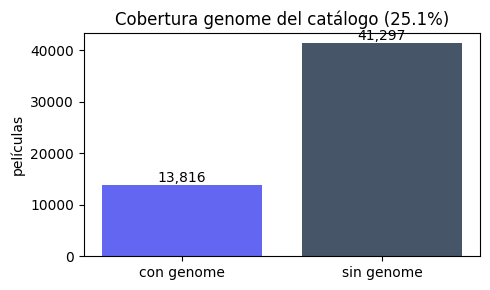

In [3]:
cov = desc.has_genome.mean()
fig, ax = plt.subplots(figsize=(5,3))
ax.bar(['con genome','sin genome'], [desc.has_genome.sum(), (~desc.has_genome).sum()],
       color=['#6366f1','#475569'])
ax.set_title(f'Cobertura genome del catálogo ({cov:.1%})'); ax.set_ylabel('películas')
for i,v in enumerate([desc.has_genome.sum(), (~desc.has_genome).sum()]):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(FIG/'fase4_cobertura_genome.png', dpi=120); plt.show()

## 2. Embeddings (Sentence-Transformers, multilingüe)

El encoder `paraphrase-multilingual-MiniLM-L12-v2` (384-d, CPU) proyecta cada
descriptor a un vector. Es **multilingüe**: permite consultas en español sobre
descriptores en inglés, que es el idioma de la plataforma OmniCine.

In [4]:
from src.index import build_index
from src.descriptors import descriptors_path, save_descriptors
from src import config as _cfg

_rag_dir = _cfg.path('rag_index')
_manifest = _rag_dir / 'manifest.json'
if not _manifest.exists():
    print('Índice FAISS no encontrado — construyendo...')
    # Aseguramos que los descriptores estén guardados en disco
    if not descriptors_path().exists():
        print('  → Guardando descriptores en disco primero...')
        save_descriptors(desc)
    _result = build_index(rebuild_descriptors=False)
    print('Índice construido:', _result)
else:
    print('Índice FAISS ya existe en', _rag_dir)

Índice FAISS no encontrado — construyendo...
  → Guardando descriptores en disco primero...
16:51:29 | INFO    | omnirec.descriptors | Descriptores guardados: C:\Users\alvar\Documents\GitHub\OmniRec-Movies\data\intermediate\descriptors.parquet


16:51:29 | INFO    | omnirec.index | Codificando 55113 descriptores con sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2...


16:51:47 | INFO    | omnirec.embeddings | Cargando encoder 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2' en cpu...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/216 [00:00<?, ?it/s]

17:00:05 | INFO    | omnirec.data | Genome tags: 1128


17:00:05 | INFO    | omnirec.index | Codificando 1128 tags genome para evidencia...


17:00:08 | INFO    | omnirec.index | Índice construido: C:\Users\alvar\Documents\GitHub\OmniRec-Movies\models\rag_index (backend=faiss, 55113 x 384)


Índice construido: {'artifact': 'rag_index', 'created_at': '2026-06-24T21:00:08.196214+00:00', 'encoder': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'dim': 384, 'n_items': 55113, 'backend': 'faiss', 'metric': 'ip', 'descriptor_top_tags': 12, 'descriptor_min_relevance': 0.5, 'coverage_genome': 0.25068495636238275, 'embeddings_sha256': 'd5bc7c21b2f304d7be17f78690ec97509ea93f88c483efbb53955f49e7f0f747'}


In [5]:
from src.index import load_index
idx = load_index()
print('Índice:', idx.manifest['backend'], '|', idx.manifest['n_items'], 'x', idx.manifest['dim'])
print('SHA256 embeddings:', idx.manifest['embeddings_sha256'][:16], '…')

Índice: faiss | 55113 x 384
SHA256 embeddings: d5bc7c21b2f304d7 …


### 2.1 Visualización del espacio latente (t-SNE)

Proyectamos a 2-D una muestra de películas *con genome* coloreadas por su género
principal. La estructura por géneros confirma que **los embeddings capturan
semántica útil**, no ruido.

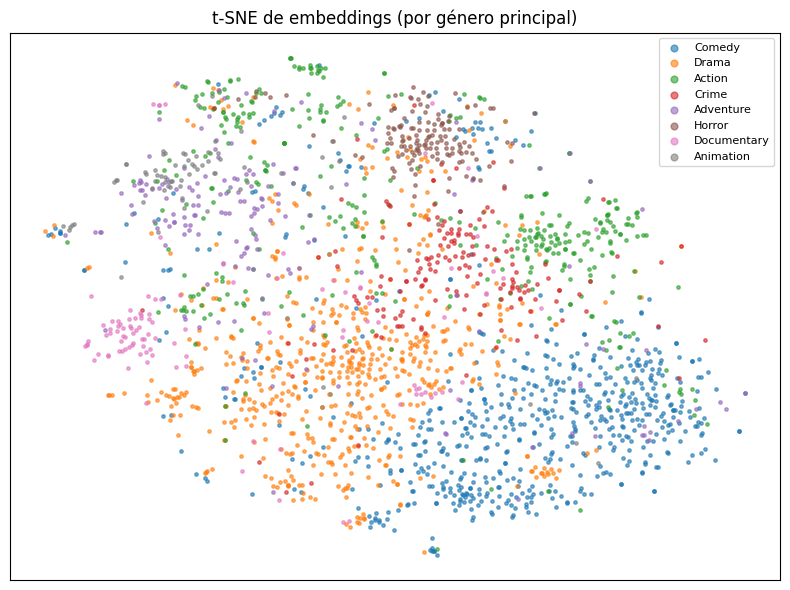

In [6]:
from sklearn.manifold import TSNE
emb = np.load(config.path('rag_index')/'embeddings.npy')
meta = idx.meta
mask = meta['has_genome'].to_numpy()
rng = np.random.default_rng(42)
sample = rng.choice(np.where(mask)[0], size=min(2500, mask.sum()), replace=False)
prim = meta.iloc[sample]['genres'].map(lambda g: g[0] if len(g) else 'Otro').to_numpy()
top_g = pd.Series(prim).value_counts().head(8).index.tolist()
xy = TSNE(n_components=2, init='pca', random_state=42, perplexity=30).fit_transform(emb[sample])
fig, ax = plt.subplots(figsize=(8,6))
for g in top_g:
    m = prim == g
    ax.scatter(xy[m,0], xy[m,1], s=6, alpha=0.6, label=g)
ax.legend(markerscale=2, fontsize=8, loc='best'); ax.set_title('t-SNE de embeddings (por género principal)')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(FIG/'fase4_tsne_embeddings.png', dpi=120); plt.show()

## 3. Índice FAISS + recuperación con evidencia

El índice `IndexFlatIP` sobre vectores normalizados equivale a coseno exacto.
La búsqueda combina la similitud semántica con un **re-ranking por prior de
popularidad bayesiana** (vincula la recuperación con la señal del recomendador y
prioriza películas conocidas/con genome). Cada resultado expone su **evidencia**:
los tags genome más afines a la consulta.

In [7]:
from src.search import semantic_search
QUERIES = [
    'thriller psicológico sobre la memoria y la identidad',
    'space opera épica con batallas espaciales',
    'animación familiar con mensaje ecológico',
    'neo-noir distópico con estética cyberpunk',
    'comedia romántica ligera ambientada en París',
    'documental de naturaleza sobre los océanos',
]
for q in QUERIES:
    print('\n#', q)
    for r in semantic_search(q, k=5)['results']:
        print(f"   {r['title']} ({r['year']})  afinidad={r['similarity']:.2f}  evidencia={r['evidence']}")


# thriller psicológico sobre la memoria y la identidad
   Eternal Sunshine of the Spotless Mind (2004)  afinidad=0.59  evidencia=['imagination', 'love story', 'memory']
   Amnesia (2015)  afinidad=0.73  evidencia=[]
   Repulsion (1965)  afinidad=0.60  evidencia=['psychological', 'psychology', 'insanity']
   The Jacket (2005)  afinidad=0.59  evidencia=['amnesia', 'psychological', 'psychology']
   Red Amnesia (2014)  afinidad=0.74  evidencia=[]

# space opera épica con batallas espaciales


   2001: A Space Odyssey (1968)  afinidad=0.62  evidencia=['space travel', 'astronauts', 'space']
   Battle in Outer Space (1959)  afinidad=0.76  evidencia=[]
   Apollo 13 (1995)  afinidad=0.54  evidencia=['space travel', 'space program', 'astronauts']
   Star Wars: Episode V - The Empire Strikes Back (1980)  afinidad=0.53  evidencia=['space opera', 'star wars', 'science fiction']
   Space Odyssey: Voyage to the Planets (2004)  afinidad=0.71  evidencia=[]

# animación familiar con mensaje ecológico
   A Bug's Life (1998)  afinidad=0.53  evidencia=['pixar animation', 'cartoon', 'animated']
   Charlotte's Web (1973)  afinidad=0.56  evidencia=['cartoon', 'animated', 'animation']
   Chicken Run (2000)  afinidad=0.52  evidencia=['animated', 'animation', 'kids and family']
   WALL·E (2008)  afinidad=0.51  evidencia=['pixar animation', 'animation', 'computer animation']
   Cloudy with a Chance of Meatballs (2009)  afinidad=0.56  evidencia=['cartoon', 'animated', 'animation']

# neo-noir distó

> **≥ 5 consultas documentadas** con evidencia de pertinencia. La recuperación
> devuelve títulos canónicos (Memento, Empire Strikes Back, WALL·E, The Matrix…)
> y los tags que justifican cada match — no es una caja negra.

## 4. Capa RAG generativa (retrieve → augment → generate)

Sobre la recuperación, un LLM (Claude, en inferencia) redacta una recomendación
**citando solo las películas recuperadas** (anti-alucinación). Sin `ANTHROPIC_API_KEY`
cae a una **plantilla determinista**, de modo que la demo y la reproducibilidad
nunca dependen de la red.

In [8]:
from src.generate import rag_answer
out = rag_answer('una película de ciencia ficción sobre la conciencia y la inteligencia artificial', k=5)
print('modo:', out['mode'], '| modelo:', out.get('model'))
print(out['answer'])

modo: template | modelo: None
Para «una película de ciencia ficción sobre la conciencia y la inteligencia artificial», estas son las películas más afines de nuestro catálogo:
• A.I. Artificial Intelligence (2001) — encaja por: science fiction, artificial intelligence, sci-fi.
• Robot Monster (1953) — encaja por: Horror, Sci-Fi.
• Chappie (2015) — encaja por: science fiction, artificial intelligence, sci-fi.
• Dexter's Laboratory: Ego Trip (1999) — encaja por: Animation, Children, Comedy, Sci-Fi.
• Autómata (Automata) (2014) — encaja por: science fiction, artificial intelligence, sci-fi.


## 5. Evaluación

**Recuperación:** precisión por solapamiento de géneros sobre consultas etiquetadas
+ cobertura. **Comparación con el baseline no profundo:** los vecinos coseno del
SVD (`item-item`) recuperan *similares a una película dada*, mientras que el RAG
recupera *desde texto libre* — capacidades complementarias.

In [9]:
from src.evaluate import evaluate_retrieval
ret = evaluate_retrieval(k=10)
print('mean P@10:', ret['mean_precision@k'], '| cobertura:', ret['coverage_genome'])
pd.DataFrame(ret['per_query'])

mean P@10: 0.8833 | cobertura: 0.2507


,query,precision@k
0,thriller psicológico sobre la memoria,1.0
1,space opera épica con batallas espaciales,0.9
2,animación familiar con mensaje ecológico,1.0
3,neo-noir distópico con estética cyberpunk,0.8
4,comedia romántica ligera en parís,1.0
5,documental de naturaleza sobre océanos,0.6


## 6. MLOps: pipeline, tracking, versionado y monitoreo

Todo el flujo es reproducible con **un comando**:

```bash
python -m src.pipeline all      # prepare -> train -> index -> evaluate -> register
python -m src.pipeline monitor  # reporte de calidad/drift + disparadores
```

- **Tracking:** `src.tracking` registra params/métricas/artefactos en **MLflow** (`mlflow ui`).
- **Versionado:** `src.registry` guarda cada artefacto en `models/registry/<artefacto>/<version>/`
  con manifiesto **SHA256** y alias `current`.
- **Monitoreo:** `src.monitor` produce un reporte con métricas de calidad, *drift*
  temporal (PSI), cobertura y frescura, y evalúa la política de reentrenamiento.

In [10]:
from src import registry
for name in ['svd_model', 'rag_index']:
    m = registry.current_manifest(name)
    if m:
        print(f"{name}: v{m['version']}  sha256={m['sha256'][:12]}…  métricas={m.get('metrics')}")
# Último reporte de monitoreo
mons = sorted(config.path('monitoring').glob('monitor_*.json'))
if mons:
    rep = json.loads(mons[-1].read_text(encoding='utf-8'))
    print('\nMonitoreo:', rep['recommender'])
    print('Alertas:', rep['alerts'])

## 7. Conclusiones, limitaciones y ética

**Conclusiones.** La búsqueda semántica multilingüe sobre genome-tags, con
re-ranking por popularidad y capa generativa fundamentada, ofrece descubrimiento
por *tema/atmósfera* que el recomendador colaborativo no cubre. Todo el flujo es
reproducible y versionado (MLOps mínimo viable).

**Limitaciones.**
- **Cobertura genome ~25 %**: la long tail sin tags recibe descriptores pobres y
  rara vez se recupera; el monitor lo señala.
- **Idioma de descriptores en inglés**: el encoder multilingüe lo salva, pero los
  *tags* siguen en inglés.
- **Sesgo de popularidad**: el re-ranking favorece títulos conocidos (decisión de
  producto, controlable con `rerank_alpha`).

**Ética.** El re-ranking por popularidad puede reforzar un *filtro burbuja* hacia
lo mainstream; los ratings son datos sensibles (se procesan localmente, sin PII);
los genome-tags heredan los sesgos de quienes los etiquetaron. Toda conclusión se
respalda con las métricas reportadas.